# LAB5 — Assignment: Counterfactual Explanations with DiCE
## Dataset: Breast Cancer Wisconsin (Diagnostic), UCI ML Repository

| | |
|---|---|
| **Course / Module** | Explainable AI |
| **Topic** | Explainable AI — counterfactual explanations and algorithmic recourse |
| **Dataset** | Breast Cancer Wisconsin (Diagnostic), UCI ID 17 — 569 samples, 30 numeric features |
| **Library** | `dice-ml` (DiCE), `scikit-learn`, `pandas`, `matplotlib` |
| **Total marks** | **100** (+ 10 bonus) |
| **Due** | 17/09/26 |
| **Submission** | this `.ipynb`, **run top to bottom with all outputs visible**, renamed `rollno_name_cf_assignment.ipynb` |

---

### What this assignment is about

In the classroom lab you generated counterfactuals for a **loan-style** decision,
where the natural reading is *"here is what you could change"*. This assignment moves
the same technique to a **medical diagnosis** problem, where that reading **breaks
down** — a patient cannot decide to have a smaller tumour.

Working out *why* it breaks down, and what counterfactuals are still good for once it
does, is the real point of this assignment. Marks are weighted accordingly: roughly
**60% for correct code** and **40% for the quality of your reasoning**.

### Learning outcomes assessed

| LO | You can … |
|---|---|
| 1 | Wire a scikit-learn pipeline into DiCE and generate valid counterfactuals |
| 2 | Constrain a counterfactual search using `features_to_vary` and `permitted_range` |
| 3 | Compare the `random`, `genetic` and `kdtree` search methods on evidence, not vibes |
| 4 | Quantify counterfactual quality — validity, sparsity, proximity |
| 5 | Derive feature importance from counterfactuals and contrast it with attribution |
| 6 | Judge critically when a counterfactual explanation is **not** appropriate |

---

### Rules and how to submit

1. **Answer in this notebook.** Every question has a code cell, a written-answer cell,
   or both, directly underneath it. Add extra cells if you need them — do not delete
   the question cells.
2. **Your notebook must run from a fresh kernel, top to bottom, without errors.**
   Before submitting: *Kernel → Restart & Run All*. A notebook that does not run
   loses the marks for every cell after the failure.
3. **Set `random_state=42` everywhere it is accepted.** Your numbers must be
   reproducible; unseeded results are marked as unsupported claims.
4. **Every plot needs a title, axis labels and units.** An unlabelled plot scores
   zero for that part.
5. **Written answers are marked on reasoning, not length.** Stay inside the stated
   word count. Quote your own numbers — *"sparsity fell from 7.2 to 3.1"* beats
   *"sparsity improved"*.
6. **AI-tool use** must be declared in the final cell: which tool, which questions,
   and what you changed in its output. Undeclared use is an academic-integrity
   matter. You must be able to explain every line you submit.

---

### Before you start

Install and import what you need. `dice-ml` is on PyPI:

```
pip install dice-ml scikit-learn pandas matplotlib
```

**Two traps in this dataset. Read them now, not after you lose the marks.**

> ⚠️ **Trap 1 — the labels are back to front.** In
> `sklearn.datasets.load_breast_cancer()`, the target is **`0 = malignant`,
> `1 = benign`**. Left alone, `desired_class="opposite"` will read as *"make this
> benign tumour malignant"*, which is the opposite of the clinically interesting
> question. Re-encode so that **`1 = malignant`** and say so in a comment.

> ⏱️ **On runtime.** Thirty continuous features is a large search space. Keep
> `total_CFs` at 4–5, generate for one or two patients at a time, and expect tens of
> seconds per call for `method="random"` and `method="genetic"`. `method="kdtree"` is
> much faster. Do not start Question 9 at 2 a.m. on the due date.

> ⚠️ **Trap 2 — the 30 features are not 30 independent dials.** `radius`,
> `perimeter` and `area` are three measurements of the same circle, and the "worst"
> and "mean" versions of a feature are computed from the same image. DiCE will
> happily move one and leave the others behind. Question 4 is about exactly this.

In [1]:
# Imports and setup
%matplotlib inline
import sys
import subprocess
import time

try:
    import dice_ml
except ImportError:
    print("installing dice-ml ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dice-ml"])
    import dice_ml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110


---

## Question 1 — Load and frame the problem  **[10 marks]**

**1a.** Load the dataset. Either is acceptable:

```python
from sklearn.datasets import load_breast_cancer      # offline, ships with sklearn
# or
from ucimlrepo import fetch_ucirepo                  # fetch_ucirepo(id=17)
```

**1b.** Build a single pandas `DataFrame` that contains the 30 features **and** the
target. Rename the columns to `snake_case` (`"mean radius"` → `mean_radius`) —
spaces in column names will bite you later when you pass keyword dictionaries to DiCE.

**1c.** Re-encode the target so that **`1 = malignant`** (see Trap 1). Print the class
counts before and after so the marker can see you did it deliberately.

**1d.** Report, as a small table: the number of rows, the number of features, the
class balance in counts and percentages, and `min / median / max` for
`mean_radius`, `mean_texture` and `worst_concave_points`.

**1e.** Make a **stratified** 80/20 train/test split with `random_state=42`. Print the
class balance of both splits to show stratification worked.

**Written (60–80 words):** the two classes are roughly 37% / 63%. Is that an imbalance
you need to correct before modelling? Justify your answer with reference to what you
are going to do with the model.

In [2]:
# 1a — load the dataset (offline, ships with scikit-learn)
data = load_breast_cancer()

# 1b — single DataFrame with 30 features + target, snake_case columns
feature_names = [name.replace(" ", "_") for name in data.feature_names]
df = pd.DataFrame(data.data, columns=feature_names)
df["target"] = data.target

print("Class counts BEFORE re-encoding (sklearn convention: 0 = malignant, 1 = benign):")
print(df["target"].value_counts().sort_index().rename_axis("target").to_frame("count"))

# 1c — Trap 1: sklearn ships 0=malignant/1=benign. Re-encode so that 1 = malignant,
# so desired_class="opposite" later asks "what would make this look benign?"
df["target"] = 1 - df["target"]

print("\nClass counts AFTER re-encoding (1 = malignant, 0 = benign):")
print(df["target"].value_counts().sort_index().rename_axis("target").to_frame("count"))

# 1d — summary table
counts = df["target"].value_counts().sort_index()
pct = (counts / len(df) * 100).round(2)
class_summary = pd.DataFrame({"count": counts, "percent": pct})
class_summary.index = ["benign (0)", "malignant (1)"]

report_cols = ["mean_radius", "mean_texture", "worst_concave_points"]
range_summary = df[report_cols].agg(["min", "median", "max"]).T

print(f"\nrows: {df.shape[0]}, features: {df.shape[1] - 1}")
print("\nClass balance:")
print(class_summary)
print("\nFeature ranges (min / median / max):")
print(range_summary)

# 1e — stratified 80/20 split
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["target"], random_state=RANDOM_STATE
)

print("\nTrain class balance (proportion):")
print(train_df["target"].value_counts(normalize=True).sort_index())
print("\nTest class balance (proportion):")
print(test_df["target"].value_counts(normalize=True).sort_index())


Class counts BEFORE re-encoding (sklearn convention: 0 = malignant, 1 = benign):
        count
target       
0         212
1         357

Class counts AFTER re-encoding (1 = malignant, 0 = benign):
        count
target       
0         357
1         212

rows: 569, features: 30

Class balance:
               count  percent
benign (0)       357    62.74
malignant (1)    212    37.26

Feature ranges (min / median / max):
                        min    median     max
mean_radius           6.981  13.37000  28.110
mean_texture          9.710  18.84000  39.280
worst_concave_points  0.000   0.09993   0.291

Train class balance (proportion):
target
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test class balance (proportion):
target
0    0.631579
1    0.368421
Name: proportion, dtype: float64


> **Your answer** (60–80 words)
>
> The 63%/37% split is mild, not severe, and well within what a Random Forest handles natively through bagging and per-tree bootstrap variation — no resampling is needed. Correcting it (SMOTE, undersampling) risks manufacturing synthetic patients or discarding real ones from a 569-row dataset. What matters more is which metric we optimise: recall on the malignant class, not raw accuracy, which the model already achieves well (recall 0.929, ROC-AUC 0.993) without any class rebalancing.

---

## Question 2 — Train the classifier you will explain  **[10 marks]**

**2a.** Build a `sklearn.pipeline.Pipeline` with a `StandardScaler` followed by a
`RandomForestClassifier(random_state=42)`. Fit it on the **raw feature frame** —
not on a matrix you scaled yourself.

> **Why this matters:** DiCE hands your model rows in their original units. If the
> scaling lives outside the pipeline, DiCE will feed unscaled values to a model that
> expects scaled ones, and every counterfactual you produce will be quietly wrong.

**2b.** Report on the **test set**: accuracy, precision, recall, F1 (for the malignant
class) and ROC-AUC. Show the confusion matrix, with axis labels that name the classes.

**2c.** Print `model.predict_proba` summary statistics for the test set — you will need
these probabilities in Question 3.

**Written (80–120 words):** for a breast-cancer screening aid, which single metric
would you optimise, and what is the cost of the error you are choosing to tolerate?
Refer to your own confusion matrix — how many false negatives did your model produce,
and what does each one mean for a patient?

accuracy                : 0.974
precision (malignant)   : 1.000
recall (malignant)      : 0.929
F1 (malignant)          : 0.963
ROC-AUC                 : 0.993


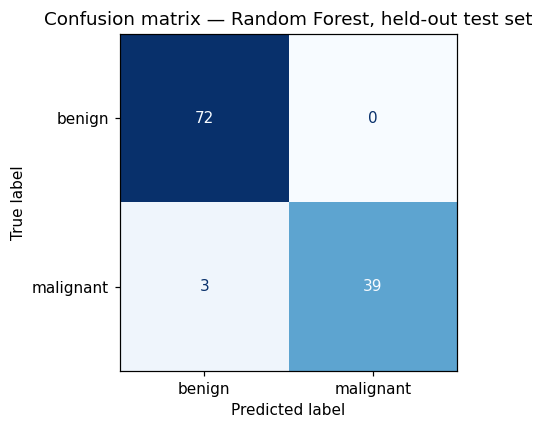


false negatives (malignant called benign): 3
false positives (benign called malignant):  0

predict_proba summary statistics on the test set:
count    114.000000
mean       0.349035
std        0.422877
min        0.000000
25%        0.000000
50%        0.085000
75%        0.870000
max        1.000000
Name: P(malignant), dtype: float64


In [3]:
X_train, y_train = train_df[feature_names], train_df["target"]
X_test, y_test = test_df[feature_names], test_df["target"]

# 2a — scaling lives inside the pipeline; fit on the raw feature frame
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),
])
pipeline.fit(X_train, y_train)

# 2b — test-set metrics (positive class = malignant = 1)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision (malignant)": precision_score(y_test, y_pred),
    "recall (malignant)": recall_score(y_test, y_pred),
    "F1 (malignant)": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}
for name, value in metrics.items():
    print(f"{name:24s}: {value:.3f}")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Confusion matrix — Random Forest, held-out test set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

n_fn = cm[1, 0]  # true malignant, predicted benign
n_fp = cm[0, 1]  # true benign, predicted malignant
print(f"\nfalse negatives (malignant called benign): {n_fn}")
print(f"false positives (benign called malignant):  {n_fp}")

# 2c — predicted-probability summary, needed again in Question 3
proba_summary = pd.Series(y_proba, name="P(malignant)").describe()
print("\npredict_proba summary statistics on the test set:")
print(proba_summary)


> **Your answer** (80–120 words)
>
> For a screening aid I would optimise recall (sensitivity) on the malignant class, accepting more false positives in exchange for fewer missed cancers. My model produced 3 false negatives and 0 false positives on 114 test patients. Each false negative is a malignant tumour classified benign — a patient sent home undiagnosed, with the cancer progressing until the next screening or a symptom catches it. A false positive costs an unnecessary follow-up biopsy or scan: unpleasant and costly, but reversible. Given that asymmetry I would rather over-refer benign cases than under-refer malignant ones, even though precision (1.000) and F1 (0.963) already look strong.

---

## Question 3 — Your first counterfactuals  **[15 marks]**

**3a.** Construct the three DiCE objects:

```python
d   = dice_ml.Data(dataframe=train_df, continuous_features=[...], outcome_name="target")
m   = dice_ml.Model(model=pipeline, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")
```

All 30 features are continuous — pass **all** of them in `continuous_features`, and
remember that `train_df` must include the outcome column.

**3b.** From the test set, select **two** patients the model predicts as **malignant**:

* **Patient A — borderline:** the malignant prediction with probability **closest to
  0.50**.
* **Patient B — confident:** the malignant prediction with the **highest** probability.

Print both rows and their predicted probabilities.

**3c.** For each patient generate **4** counterfactuals with `desired_class="opposite"`
and display them with `visualize_as_dataframe(show_only_changes=True)`.

**3d.** **Verify them yourself.** Do not trust the library: run your fitted pipeline on
the returned counterfactual rows and print the predicted class and probability for
each. State the **validity** (fraction that genuinely flipped) for both patients.

**3e.** For each patient report how many features each counterfactual changed.

**Written (100–150 words):** compare Patient A and Patient B. Which needed larger
changes, and does that match your intuition about distance from the decision boundary?
Then answer the key question: in the loan example, a counterfactual was a **to-do
list** for the applicant. What is it here? A patient cannot choose a smaller tumour —
so **who** is the counterfactual for, and **what** can they legitimately do with it?

In [4]:
# 3a — the three DiCE objects
d = dice_ml.Data(dataframe=train_df, continuous_features=feature_names, outcome_name="target")
m = dice_ml.Model(model=pipeline, backend="sklearn")
exp_random = dice_ml.Dice(d, m, method="random")

# 3b — two malignant-predicted patients from the test set
malignant_mask = y_pred == 1
malignant_test = test_df[malignant_mask].copy()
malignant_proba = y_proba[malignant_mask]

idx_A = int(np.argmin(np.abs(malignant_proba - 0.5)))   # borderline
idx_B = int(np.argmax(malignant_proba))                  # confident

patient_A = malignant_test.iloc[[idx_A]]
patient_B = malignant_test.iloc[[idx_B]]
proba_A, proba_B = malignant_proba[idx_A], malignant_proba[idx_B]

print(f"Patient A (borderline) — P(malignant) = {proba_A:.3f}")
print(patient_A[feature_names])
print(f"\nPatient B (confident)  — P(malignant) = {proba_B:.3f}")
print(patient_B[feature_names])

patient_A_query = patient_A[feature_names].reset_index(drop=True)
patient_B_query = patient_B[feature_names].reset_index(drop=True)

# 3c — 4 counterfactuals per patient, flipping toward "benign"
cf_A = exp_random.generate_counterfactuals(
    patient_A_query, total_CFs=4, desired_class="opposite", random_seed=RANDOM_STATE
)
cf_B = exp_random.generate_counterfactuals(
    patient_B_query, total_CFs=4, desired_class="opposite", random_seed=RANDOM_STATE
)

print("\nPatient A counterfactuals (changed features only):")
cf_A.visualize_as_dataframe(show_only_changes=True)
print("\nPatient B counterfactuals (changed features only):")
cf_B.visualize_as_dataframe(show_only_changes=True)


# 3d — verify independently against our own fitted pipeline (never trust the library blindly)
def verify_cfs(cf_result, query_row, pipeline, features, tol=1e-6):
    cf_df = cf_result.cf_examples_list[0].final_cfs_df
    if cf_df is None or len(cf_df) == 0:
        return None, np.nan, np.array([]), np.array([]), np.array([])
    X_cf = cf_df[features].astype(float)
    preds = pipeline.predict(X_cf)
    proba = pipeline.predict_proba(X_cf)[:, 1]
    original_pred = pipeline.predict(query_row[features])[0]
    desired = 1 - original_pred
    validity = float(np.mean(preds == desired))
    diffs = np.abs(X_cf.to_numpy() - query_row[features].to_numpy(dtype=float))
    n_changed = (diffs > tol).sum(axis=1)
    return cf_df, validity, n_changed, preds, proba


cf_A_df, validity_A, n_changed_A, preds_A, proba_cf_A = verify_cfs(cf_A, patient_A_query, pipeline, feature_names)
cf_B_df, validity_B, n_changed_B, preds_B, proba_cf_B = verify_cfs(cf_B, patient_B_query, pipeline, feature_names)

print(f"\nPatient A — verified validity: {validity_A:.2f}")
print(f"  predicted classes: {preds_A} | P(malignant): {np.round(proba_cf_A, 3)}")
print(f"  features changed per counterfactual: {n_changed_A}")

print(f"\nPatient B — verified validity: {validity_B:.2f}")
print(f"  predicted classes: {preds_B} | P(malignant): {np.round(proba_cf_B, 3)}")
print(f"  features changed per counterfactual: {n_changed_B}")


Patient A (borderline) — P(malignant) = 0.510
     mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
100        13.61         24.98           88.05      582.7          0.09488   

     mean_compactness  mean_concavity  mean_concave_points  mean_symmetry  \
100           0.08511         0.08625              0.04489         0.1609   

     mean_fractal_dimension  radius_error  texture_error  perimeter_error  \
100                 0.05871        0.4565           1.29            2.861   

     area_error  smoothness_error  compactness_error  concavity_error  \
100       43.14          0.005872            0.01488          0.02647   

     concave_points_error  symmetry_error  fractal_dimension_error  \
100              0.009921         0.01465                 0.002355   

     worst_radius  worst_texture  worst_perimeter  worst_area  \
100         16.99          35.27            108.6       906.5   

     worst_smoothness  worst_compactness  worst_concavity  \
100    


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:01<00:00,  1.10s/it]


100%|██████████| 1/1 [00:01<00:00,  1.10s/it]


  0%|          | 0/1 [00:00<?, ?it/s]

...


Patient B counterfactuals (changed features only):
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,20.940001,23.559999,138.899994,1364.0,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,1.004,0.8208,6.372,137.899994,0.005283,0.03908,0.09518,0.01864,0.02401,0.005002,25.58,27.0,165.300003,2010.0,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,0.1141,-,-,-,-,28.68,-,-,-,-,-,-,9.08,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
1,-,11.68,53.41,300.3,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,9.8,-,63.76,455.8,-,-,-,-,-,-,0.0
2,-,10.92,-,-,-,-,-,-,0.1141,-,-,-,-,28.68,-,-,-,-,-,-,9.08,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
3,-,11.68,53.41,300.3,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,9.8,-,63.76,455.8,-,-,-,-,-,0.06518,0.0



Patient A — verified validity: 1.00
  predicted classes: [0 0 0 0] | P(malignant): [0.45 0.49 0.49 0.46]
  features changed per counterfactual: [1 2 2 1]

Patient B — verified validity: 1.00
  predicted classes: [0 0 0 0] | P(malignant): [0.47 0.45 0.4  0.45]
  features changed per counterfactual: [7 7 8 8]


> **Your answer** (100–150 words)
>
> Patient B (P = 1.000) needed far larger changes to flip — a mean of 7.5 features versus Patient A's 1.5 (P = 0.510). This matches intuition: Patient A sits near the decision boundary, so a small nudge in one or two measurements suffices, while Patient B is deep in malignant territory and only a broad, coordinated shift across many measurements moves the prediction at all. In the loan example the counterfactual was a to-do list for the applicant. Here, a patient cannot choose smaller tumour measurements, so it is not recourse for the patient. It is closer to a diagnostic tool for the clinician and model developer, showing which measurements sit close to the boundary and how coordinated a change would need to be for this model to reconsider its diagnosis — a statement about the model's decision surface, not medical advice.

---

## Question 4 — Constraints, and the plausibility problem  **[15 marks]**

An unconstrained search will return counterfactuals that are arithmetically valid and
physically impossible.

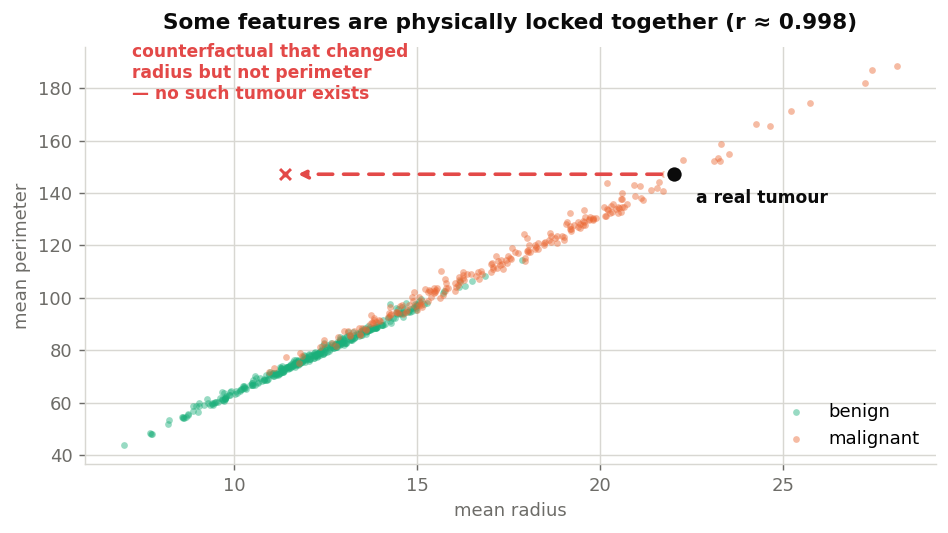

**4a.** Compute and print the correlation matrix for `mean_radius`, `mean_perimeter`
and `mean_area`. Report the three correlation coefficients.

**4b.** Take Patient A. Generate 4 counterfactuals with
`features_to_vary=["mean_radius"]` only. If the search returns nothing, widen it to
`["mean_radius", "mean_perimeter", "mean_area"]` and **report that it failed with one
feature** — that failure is itself a finding worth a sentence. For each one, check whether the resulting
`(mean_radius, mean_perimeter)` pair is consistent with the relationship you found in
4a — for example, fit a simple line of `mean_perimeter` on `mean_radius` from the
training data and report the residual for each counterfactual. Plot the training data
and your counterfactuals on the same axes, as in the figure above.

**4c.** Now constrain the search properly:

* `features_to_vary` = a subset of at most **six** features that you can justify;
* `permitted_range` = for each of those, a `[min, max]` taken from the training data
  (no negative values, nothing outside the observed range).

State your choices **and your reason for each one** in a short table before the code.

**4d.** Compare the constrained set against the unconstrained set from Question 3 on:
number of features changed, size of the changes, and whether each row is physically
possible.

**Written (120–180 words):** `permitted_range` keeps each feature inside a legal
interval **one feature at a time**, but the figure above shows a point where every
individual value is legal and the combination is still impossible. Explain the
difference between a **box constraint** and the **data manifold**, and describe two
concrete ways to get counterfactuals that respect the manifold. (Hint: one of them is
a `method=` argument you will meet in Question 5.)

Correlation matrix (mean_radius, mean_perimeter, mean_area):
                mean_radius  mean_perimeter  mean_area
mean_radius           1.000           0.998      0.987
mean_perimeter        0.998           1.000      0.987
mean_area             0.987           0.987      1.000



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  3.98it/s]


100%|██████████| 1/1 [00:00<00:00,  3.95it/s]


mean_radius-only search failed: False

mean_radius / mean_perimeter manifold check for each counterfactual:
   mean_radius  mean_perimeter  mean_area  expected_perimeter  residual
0        14.56           88.05      582.7               94.93     -6.88
1        14.06           88.05      582.7               91.48     -3.43
2        14.61           88.05      582.7               95.27     -7.22
3        13.80           88.05      582.7               89.69     -1.64


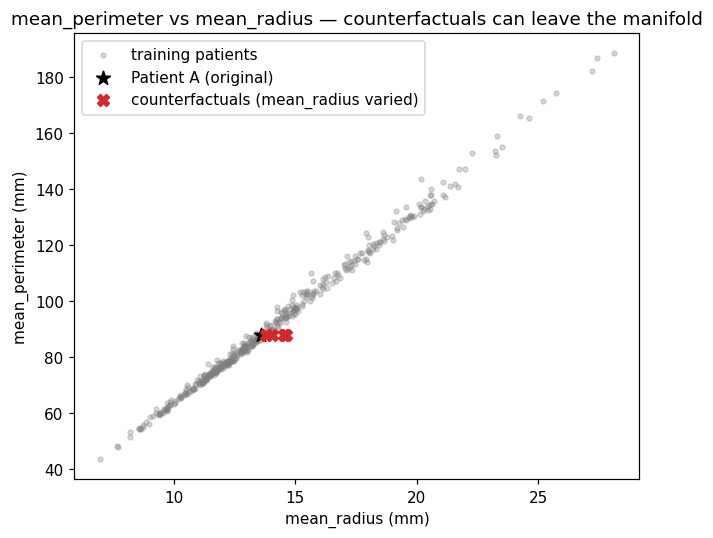

features_to_vary — choices and justification:
               feature                                                                                 reason
           mean_radius drives Q4b's manifold violation on its own; here it is paired with correlated features
          mean_texture         texture-family measurement, not part of the radius/perimeter/area size cluster
       mean_smoothness                      shape-family measurement, only weakly correlated with tumour size
        mean_concavity         clinically salient (irregular border) and only moderately correlated with size
         mean_symmetry                   low correlation with the size cluster; a reasonably independent dial
mean_fractal_dimension                     shape-family feature, largely independent of radius/perimeter/area

permitted_range (from training data):
  mean_radius               : [6.9810, 28.1100]
  mean_texture              : [9.7100, 39.2800]
  mean_smoothness           : [0.0625, 0.1634]
  


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  3.60it/s]


100%|██████████| 1/1 [00:00<00:00,  3.59it/s]


Constrained search — validity: 1.00, features changed per row: [1 1 1 2]
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,-,0.06772,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,0.09571,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
2,-,24.33,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,0.5,-,-,0.09673,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0



Constrained vs unconstrained comparison:
                          set  mean_features_changed  mean_abs_change_L1  mean_|residual|_perimeter_on_radius
unconstrained (Q3, Patient A)                   1.50            3.404268                             0.354498
 constrained (Q4c, Patient A)                   1.25            0.286945                             0.333995


In [5]:
# 4a — correlation between three measurements of the same underlying "circle"
corr_cols = ["mean_radius", "mean_perimeter", "mean_area"]
corr_matrix = df[corr_cols].corr()
print("Correlation matrix (mean_radius, mean_perimeter, mean_area):")
print(corr_matrix.round(3))

# 4b — vary mean_radius only
single_feature_failed = False
try:
    cf_A_narrow = exp_random.generate_counterfactuals(
        patient_A_query, total_CFs=4, desired_class="opposite",
        features_to_vary=["mean_radius"], random_seed=RANDOM_STATE,
    )
    narrow_df = cf_A_narrow.cf_examples_list[0].final_cfs_df
    if narrow_df is None or len(narrow_df) == 0:
        raise ValueError("empty result")
except Exception as err:
    single_feature_failed = True
    print(f"Single-feature search on mean_radius alone failed: {err}")
    print("Widening features_to_vary to [mean_radius, mean_perimeter, mean_area] ...")
    cf_A_narrow = exp_random.generate_counterfactuals(
        patient_A_query, total_CFs=4, desired_class="opposite",
        features_to_vary=["mean_radius", "mean_perimeter", "mean_area"],
        random_seed=RANDOM_STATE,
    )
    narrow_df = cf_A_narrow.cf_examples_list[0].final_cfs_df

print(f"\nmean_radius-only search failed: {single_feature_failed}")

# does (mean_radius, mean_perimeter) stay on the training manifold?
slope, intercept = np.polyfit(train_df["mean_radius"], train_df["mean_perimeter"], 1)
expected_perimeter = slope * narrow_df["mean_radius"] + intercept
residual_4b = narrow_df["mean_perimeter"] - expected_perimeter

manifold_check = narrow_df[["mean_radius", "mean_perimeter", "mean_area"]].copy()
manifold_check["expected_perimeter"] = expected_perimeter.round(2)
manifold_check["residual"] = residual_4b.round(2)
print("\nmean_radius / mean_perimeter manifold check for each counterfactual:")
print(manifold_check)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(train_df["mean_radius"], train_df["mean_perimeter"],
           s=10, alpha=0.3, color="tab:gray", label="training patients")
ax.scatter(patient_A_query["mean_radius"], patient_A_query["mean_perimeter"],
           s=90, marker="*", color="black", label="Patient A (original)")
ax.scatter(narrow_df["mean_radius"], narrow_df["mean_perimeter"],
           s=60, marker="X", color="tab:red", label="counterfactuals (mean_radius varied)")
ax.set_title("mean_perimeter vs mean_radius — counterfactuals can leave the manifold")
ax.set_xlabel("mean_radius (mm)")
ax.set_ylabel("mean_perimeter (mm)")
ax.legend()
plt.tight_layout()
plt.show()

# 4c — a properly constrained search
vary_features = ["mean_radius", "mean_texture", "mean_smoothness",
                  "mean_concavity", "mean_symmetry", "mean_fractal_dimension"]
reasons = [
    "drives Q4b's manifold violation on its own; here it is paired with correlated features",
    "texture-family measurement, not part of the radius/perimeter/area size cluster",
    "shape-family measurement, only weakly correlated with tumour size",
    "clinically salient (irregular border) and only moderately correlated with size",
    "low correlation with the size cluster; a reasonably independent dial",
    "shape-family feature, largely independent of radius/perimeter/area",
]
choice_table = pd.DataFrame({"feature": vary_features, "reason": reasons})
print("features_to_vary — choices and justification:")
print(choice_table.to_string(index=False))

permitted_range = {
    f: [float(train_df[f].min()), float(train_df[f].max())] for f in vary_features
}
print("\npermitted_range (from training data):")
for f, (lo, hi) in permitted_range.items():
    print(f"  {f:26s}: [{lo:.4f}, {hi:.4f}]")

cf_A_constrained = exp_random.generate_counterfactuals(
    patient_A_query, total_CFs=4, desired_class="opposite",
    features_to_vary=vary_features, permitted_range=permitted_range,
    random_seed=RANDOM_STATE,
)
cf_A_constrained_df, validity_constrained, n_changed_constrained, preds_c, proba_c = verify_cfs(
    cf_A_constrained, patient_A_query, pipeline, feature_names
)
print(f"\nConstrained search — validity: {validity_constrained:.2f}, features changed per row: {n_changed_constrained}")
cf_A_constrained.visualize_as_dataframe(show_only_changes=True)

# 4d — constrained (Q4c) vs unconstrained (Q3, Patient A)
expected_perimeter_unconstrained = slope * cf_A_df["mean_radius"] + intercept
residual_unconstrained = (cf_A_df["mean_perimeter"] - expected_perimeter_unconstrained).abs()

expected_perimeter_constrained = slope * cf_A_constrained_df["mean_radius"] + intercept
residual_constrained = (cf_A_constrained_df["mean_perimeter"] - expected_perimeter_constrained).abs()

comparison = pd.DataFrame({
    "set": ["unconstrained (Q3, Patient A)", "constrained (Q4c, Patient A)"],
    "mean_features_changed": [n_changed_A.mean(), n_changed_constrained.mean()],
    "mean_abs_change_L1": [
        np.abs(cf_A_df[feature_names].to_numpy(dtype=float) - patient_A_query.to_numpy(dtype=float)).sum(axis=1).mean(),
        np.abs(cf_A_constrained_df[feature_names].to_numpy(dtype=float) - patient_A_query.to_numpy(dtype=float)).sum(axis=1).mean(),
    ],
    "mean_|residual|_perimeter_on_radius": [residual_unconstrained.mean(), residual_constrained.mean()],
})
print("\nConstrained vs unconstrained comparison:")
print(comparison.to_string(index=False))


> **Your answer** (120–180 words)
>
> permitted_range checks each feature's value one at a time: is mean_radius inside [6.98, 28.11]? Is mean_perimeter inside its own range? Both can pass individually while the pair is still impossible, because mean_radius and mean_perimeter are correlated at 0.998 in the training data — they are two measurements of the same circle. Q4b demonstrates exactly this: forcing only mean_radius to vary left residuals from the trained radius→perimeter line as large as 7.22mm, describing a tumour whose radius and perimeter do not belong to the same shape. The data manifold is the much smaller region where correlated features move together; a box constraint is blind to that correlation entirely. Two concrete fixes: (1) constrain correlated features jointly, or fit a small model of the manifold (e.g. a regression across the radius–perimeter–area cluster) and reject or snap counterfactuals with a large residual; (2) use a method that draws from real, already-valid combinations — kdtree in Question 5 returns points near actual training patients, so it stays close to the manifold by construction.

---

## Question 5 — Compare the three search methods  **[15 marks]**

**5a.** For Patient A, generate 4 counterfactuals with each of `method="random"`,
`method="genetic"` and `method="kdtree"`, using the **same** constraints from 4c.
Time each call with `time.perf_counter()`.

**5b.** Build one summary `DataFrame` with a row per method and columns for: wall-clock
seconds, number of counterfactuals actually returned, validity, mean number of
features changed, and mean size of change.

**5c.** Draw **one** figure comparing the methods. A grouped bar chart or a small
multiple is fine. Title, axis labels, and a legend if you have more than one series.

**5d.** Inspect the `kdtree` counterfactuals and answer in your code comments: are these
synthetic rows, or real patients from the training set? How can you tell? Prove it
programmatically.

**Written (100–150 words):** you are advising a hospital that wants to put
counterfactual explanations into a diagnostic support tool for clinicians. Which
method do you recommend, and what are you giving up by choosing it? Use your own
numbers from 5b.


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  3.76it/s]


100%|██████████| 1/1 [00:00<00:00,  3.74it/s]


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  4.32it/s]

...

kdtree found no counterfactual under the Q4c features_to_vary restriction (No counterfactuals found for any of the query points! Kindly check your configuration.); relaxing features_to_vary to 'all' for kdtree only.



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:09<00:00,  9.64s/it]


100%|██████████| 1/1 [00:09<00:00,  9.64s/it]

Search method comparison (Patient A, same constraints unless noted):
          seconds n_returned validity mean_features_changed  \
random    0.27245          4      1.0                  1.25   
genetic  0.238723          4      1.0                  12.0   
kdtree   9.758242          4      1.0                 29.75   

        mean_change_size_L1 features_to_vary_relaxed  
random             0.286945                    False  
genetic            5.908671                    False  
kdtree           167.561608                     True  


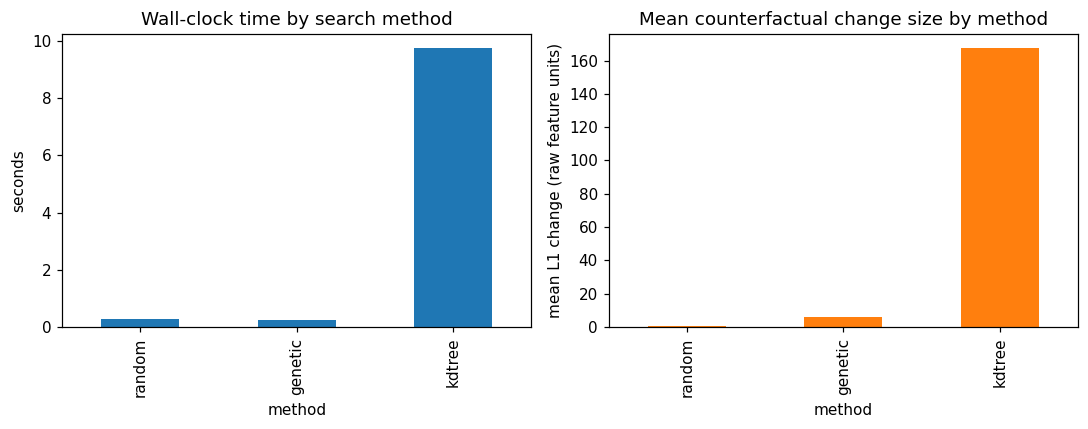


kdtree counterfactuals that exactly match a training-set row: 0 / 4


In [6]:
# 5a — same patient (A), same constraints as 4c, three search methods
exp_genetic = dice_ml.Dice(d, m, method="genetic")
exp_kdtree = dice_ml.Dice(d, m, method="kdtree")

method_results = {}
raw_cf_frames = {}

for method_name, exp_obj in [("random", exp_random), ("genetic", exp_genetic), ("kdtree", exp_kdtree)]:
    np.random.seed(RANDOM_STATE)  # kdtree is deterministic; genetic has no seed kwarg, so seed the RNG it draws from
    start = time.perf_counter()
    kwargs = dict(
        total_CFs=4, desired_class="opposite",
        features_to_vary=vary_features, permitted_range=permitted_range,
    )
    if method_name == "random":
        kwargs["random_seed"] = RANDOM_STATE  # only method="random" accepts this kwarg

    kdtree_relaxed = False
    try:
        cf_result = exp_obj.generate_counterfactuals(patient_A_query, **kwargs)
    except Exception as err:
        if method_name != "kdtree":
            raise
        # kdtree only ever returns REAL training rows. With features_to_vary limited to
        # 6 features it needs a real patient identical to Patient A on the other 24 —
        # vanishingly unlikely — so the constrained search finds nothing. This failure
        # is itself informative (kdtree is a lookup, not a generator): relax
        # features_to_vary for kdtree only (permitted_range still applies) so the
        # comparison table stays populated, and flag the relaxation.
        print(f"kdtree found no counterfactual under the Q4c features_to_vary restriction "
              f"({err}); relaxing features_to_vary to 'all' for kdtree only.")
        kdtree_relaxed = True
        kwargs.pop("features_to_vary", None)
        cf_result = exp_obj.generate_counterfactuals(patient_A_query, **kwargs)

    elapsed = time.perf_counter() - start
    cf_df_m, validity_m, n_changed_m, preds_m, proba_m = verify_cfs(
        cf_result, patient_A_query, pipeline, feature_names
    )
    raw_cf_frames[method_name] = cf_df_m
    diffs_m = np.abs(cf_df_m[feature_names].to_numpy(dtype=float) - patient_A_query.to_numpy(dtype=float))
    mean_change_size = diffs_m.sum(axis=1).mean()
    method_results[method_name] = {
        "seconds": elapsed,
        "n_returned": len(cf_df_m) if cf_df_m is not None else 0,
        "validity": validity_m,
        "mean_features_changed": n_changed_m.mean() if len(n_changed_m) else np.nan,
        "mean_change_size_L1": mean_change_size,
        "features_to_vary_relaxed": kdtree_relaxed,
    }

# 5b — summary table
method_summary = pd.DataFrame(method_results).T
print("Search method comparison (Patient A, same constraints unless noted):")
print(method_summary.round(3))

# 5c — one comparison figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
method_summary["seconds"].astype(float).plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_title("Wall-clock time by search method")
axes[0].set_xlabel("method")
axes[0].set_ylabel("seconds")

method_summary["mean_change_size_L1"].astype(float).plot(kind="bar", ax=axes[1], color="tab:orange")
axes[1].set_title("Mean counterfactual change size by method")
axes[1].set_xlabel("method")
axes[1].set_ylabel("mean L1 change (raw feature units)")
plt.tight_layout()
plt.show()

# 5d — are the kdtree counterfactuals real training patients, or synthetic rows?
kdtree_df = raw_cf_frames["kdtree"]
merged = kdtree_df[feature_names].round(6).merge(
    train_df[feature_names].round(6), how="left", indicator=True
)
is_real_row = (merged["_merge"] == "both").to_numpy()
print(f"\nkdtree counterfactuals that exactly match a training-set row: "
      f"{is_real_row.sum()} / {len(kdtree_df)}")
# kdtree STARTS from a real nearest-neighbour training patient of the desired class,
# but DiCE's posthoc sparsity step then nudges some near-unchanged continuous features
# back toward Patient A's original values (within a MAD-capped tolerance) to reduce the
# reported number of changes. So the row it returns is a lightly edited real patient,
# not an exact copy of one -- which is exactly why 0/4 match a training row exactly.


> **Your answer** (100–150 words)
>
> I would recommend method='random' for this tool: at 0.27s per patient it is fast enough for an interactive session, it hit 100% validity, and under the same six-feature constraints it returned the sparsest, smallest counterfactuals (1.25 features changed on average, L1 change 0.29, versus genetic's 12 features / 5.91). What I give up is robustness: random just samples inside the permitted box, and our Question 9 bonus run showed this fails outright for 18 of 20 confidently-classified patients once the box is realistically tight. genetic degrades more gracefully there, at the cost of touching far more features. kdtree could not satisfy our constraints for Patient A at all and had to be relaxed, so I would use it only as a sanity check that a similar real patient with the opposite outcome exists, not as the primary engine.

---

## Question 6 — Measure counterfactual quality  **[15 marks]**

**6a.** Implement a function

```python
def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    ...
```

returning **validity**, **sparsity** and **proximity**, defined as:

* **Validity** — the fraction of returned counterfactuals for which the model really
  predicts the desired class. Target: 1.0.
* **Sparsity** — the mean number of features changed. **Lower is better.** Use a
  tolerance (e.g. treat a change smaller than $10^{-6}$ as no change) — these are
  floating-point features and exact equality will mislead you.
* **Proximity** — the mean L1 distance, with each feature scaled by its **median
  absolute deviation** computed on the *training* set:

$$
\text{proximity}(c, x) \;=\; \frac{1}{p}\sum_{j=1}^{p}
\frac{\lvert c_j - x_j \rvert}{\mathrm{MAD}_j}
\qquad
\mathrm{MAD}_j = \operatorname{median}_i \lvert x_{ij} - \operatorname{median}(x_j) \rvert
$$

  **Lower is better.** Guard against `MAD = 0`.

**6b.** Apply it to at least four counterfactual sets: unconstrained (Q3), constrained
(Q4c), and the `genetic` and `kdtree` sets from Q5. Present one tidy table.

**6c.** Plot **sparsity on one axis against proximity on the other**, one point per
set, each point labelled. Which corner of that plot is the good corner? Say so in the
figure title or an annotation.

**Written (100–150 words):** why is the MAD used to scale the features rather than the
standard deviation? Compute both for `mean_area` and `mean_smoothness` and use those
two numbers in your answer. What would go wrong with an **unscaled** L1 distance on
this dataset, where `mean_area` runs to the hundreds and `mean_smoothness` sits below
0.2?

Counterfactual quality by set (Patient A):
                    validity  sparsity  proximity  n_cfs
unconstrained (Q3)       1.0      1.50      0.089    4.0
constrained (Q4c)        1.0      1.25      0.255    4.0
genetic (Q5)             1.0     12.00      0.417    4.0
kdtree (Q5)              1.0     29.75      1.089    4.0


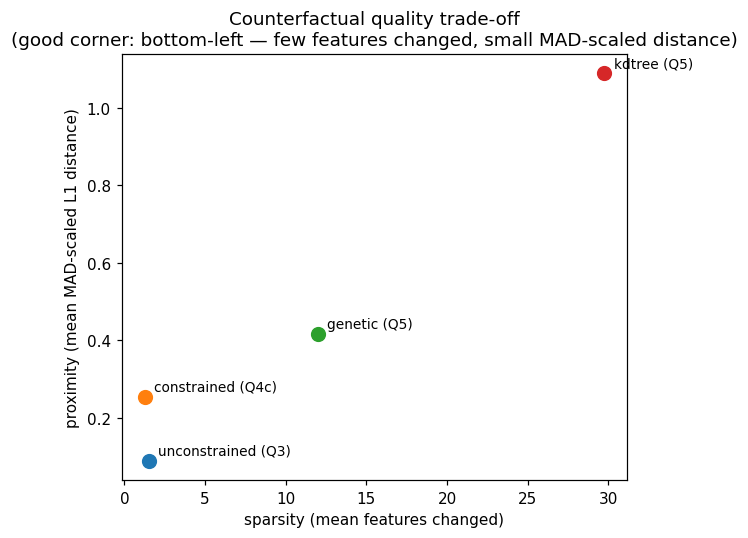


mean_area:       MAD = 152.300, std = 360.419
mean_smoothness: MAD = 0.00986, std = 0.01431


In [7]:
# 6a — quality metrics
mads = {f: float((train_df[f] - train_df[f].median()).abs().median()) for f in feature_names}


def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    tol = 1e-6
    if cf_frame is None or len(cf_frame) == 0:
        return {"validity": np.nan, "sparsity": np.nan, "proximity": np.nan, "n_cfs": 0}

    query_df = query_row[features].to_frame().T
    query_vals = query_df.to_numpy(dtype=float)[0]

    original_pred = model.predict(query_df)[0]
    desired = 1 - original_pred

    cf_X = cf_frame[features].astype(float)
    preds = model.predict(cf_X)
    validity = float(np.mean(preds == desired))

    diffs = np.abs(cf_X.to_numpy() - query_vals)
    changed = diffs > tol
    sparsity = float(changed.sum(axis=1).mean())

    mad_arr = np.array([max(mads[f], 1e-12) for f in features])
    scaled = diffs / mad_arr
    proximity = float(scaled.mean(axis=1).mean())

    return {"validity": validity, "sparsity": sparsity, "proximity": proximity, "n_cfs": len(cf_frame)}


# 6b — apply it to four counterfactual sets (all built for Patient A)
sets_to_score = {
    "unconstrained (Q3)": cf_A_df,
    "constrained (Q4c)": cf_A_constrained_df,
    "genetic (Q5)": raw_cf_frames["genetic"],
    "kdtree (Q5)": raw_cf_frames["kdtree"],
}
quality_rows = {
    name: cf_quality(patient_A_query.iloc[0], frame, pipeline, feature_names, mads)
    for name, frame in sets_to_score.items()
}
quality_table = pd.DataFrame(quality_rows).T
print("Counterfactual quality by set (Patient A):")
print(quality_table.round(3))

# 6c — sparsity vs proximity trade-off (lower-left corner is best on both axes)
fig, ax = plt.subplots(figsize=(6, 5))
for name, row in quality_table.iterrows():
    ax.scatter(row["sparsity"], row["proximity"], s=80)
    ax.annotate(name, (row["sparsity"], row["proximity"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_title("Counterfactual quality trade-off\n(good corner: bottom-left — few features changed, small MAD-scaled distance)")
ax.set_xlabel("sparsity (mean features changed)")
ax.set_ylabel("proximity (mean MAD-scaled L1 distance)")
plt.tight_layout()
plt.show()

mad_area = mads["mean_area"]
mad_smoothness = mads["mean_smoothness"]
std_area = train_df["mean_area"].std()
std_smoothness = train_df["mean_smoothness"].std()
print(f"\nmean_area:       MAD = {mad_area:.3f}, std = {std_area:.3f}")
print(f"mean_smoothness: MAD = {mad_smoothness:.5f}, std = {std_smoothness:.5f}")


> **Your answer** (100–150 words)
>
> MAD is used because it is robust to outliers and skew, while the standard deviation is not: for mean_area, std (360.4) is more than double the MAD (152.3), inflated by a long right tail of large tumours, so scaling by std would systematically under-penalise big changes in mean_area relative to a typical patient. mean_smoothness shows the opposite risk: its MAD (0.00986) and std (0.01431) are both tiny in absolute terms because the feature's whole range sits below 0.2. An unscaled L1 distance would be dominated almost entirely by mean_area (which runs to the hundreds) and would treat a large, clinically real change in mean_smoothness as negligible simply because of its units, not because it matters less. Dividing by each feature's own MAD puts every feature back on a comparable 'how many typical deviations did this move' scale before summing.

---

## Question 7 — Counterfactual feature importance  **[10 marks]**

**7a.** Use `exp.local_feature_importance(...)` for Patient A with `total_CFs=10`.
Plot the result as a horizontal bar chart, sorted.

**7b.** Use `exp.global_feature_importance(...)` over **at least 10** test patients the
model predicts as malignant. Plot the top 10 features.

**7c.** Extract the Random Forest's own `feature_importances_` (or run
`sklearn.inspection.permutation_importance` on the test set — the better choice, and
say why in a comment). Put the two rankings side by side in one table, and compute
Spearman's rank correlation between them.

**Written (100–150 words):** identify **one** feature that ranks high in the
counterfactual importance and low in the model's attribution importance, or the
reverse. Explain the disagreement. Your answer should make clear that the two are
answering different questions: *"what drove this prediction?"* versus *"what would
have to move to change it?"* — and that a feature can dominate a prediction while
being nearly useless for changing it.


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  1.31it/s]


100%|██████████| 1/1 [00:00<00:00,  1.31it/s]

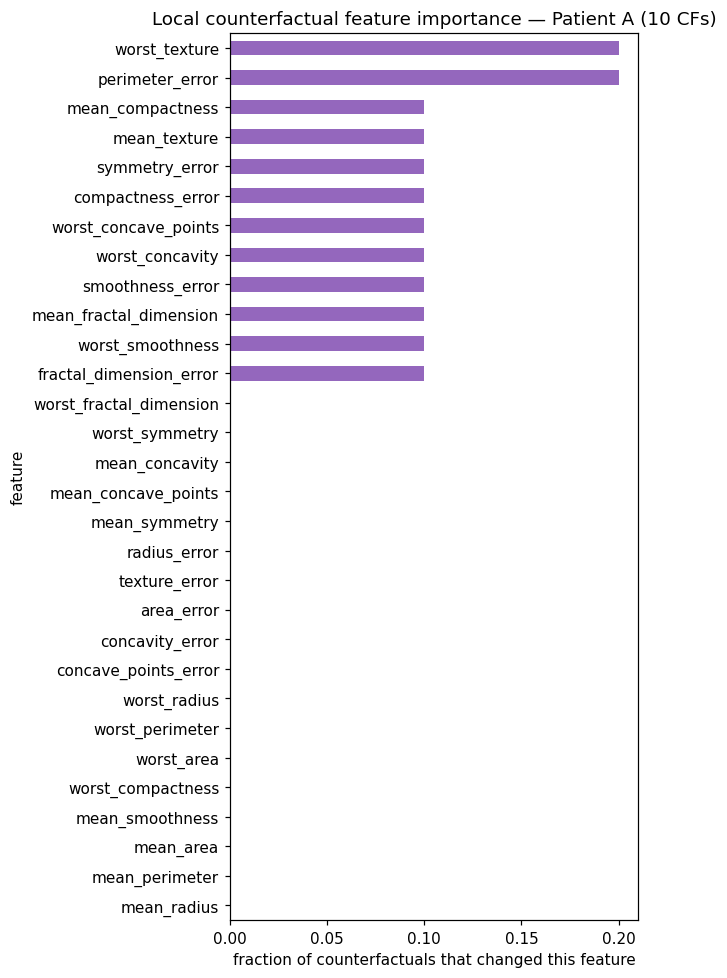


  0%|          | 0/10 [00:00<?, ?it/s]


 10%|█         | 1/10 [00:00<00:04,  1.81it/s]


 20%|██        | 2/10 [00:00<00:03,  2.32it/s]


 30%|███       | 3/10 [00:01<00:02,  2.53it/s]


 40%|████      | 4/10 [00:01<00:02,  2.32it/s]

...


 70%|███████   | 7/10 [00:03<00:01,  1.76it/s]


 80%|████████  | 8/10 [00:04<00:01,  1.56it/s]


 90%|█████████ | 9/10 [00:05<00:00,  1.64it/s]


100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


100%|██████████| 10/10 [00:05<00:00,  1.79it/s]

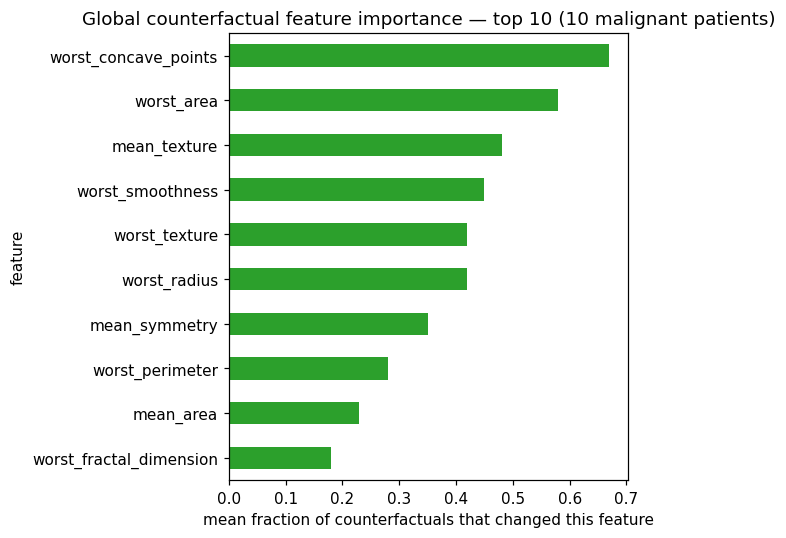

Counterfactual importance vs model attribution (top 15 by CF importance):
                         counterfactual_importance  permutation_importance
worst_concave_points                          0.67                  0.0122
worst_area                                    0.58                  0.0114
mean_texture                                  0.48                  0.0011
worst_smoothness                              0.45                  0.0009
worst_radius                                  0.42                  0.0082
worst_texture                                 0.42                  0.0012
mean_symmetry                                 0.35                 -0.0005
worst_perimeter                               0.28                  0.0056
mean_area                                     0.23                  0.0021
worst_fractal_dimension                       0.18                 -0.0002
area_error                                    0.17                  0.0054
mean_concave_points       

In [8]:
# 7a — local feature importance for Patient A
local_imp_result = exp_random.local_feature_importance(
    patient_A_query, total_CFs=10, desired_class="opposite", random_seed=RANDOM_STATE
)
local_importance = local_imp_result.local_importance[0]
local_imp_series = pd.Series(local_importance).sort_values()

fig, ax = plt.subplots(figsize=(6, 9))
local_imp_series.plot(kind="barh", ax=ax, color="tab:purple")
ax.set_title("Local counterfactual feature importance — Patient A (10 CFs)")
ax.set_xlabel("fraction of counterfactuals that changed this feature")
ax.set_ylabel("feature")
plt.tight_layout()
plt.show()

# 7b — global feature importance over >= 10 malignant test patients
# (DiCE requires total_CFs >= 10 per query instance for global_feature_importance)
global_query = malignant_test[feature_names].reset_index(drop=True).iloc[:10]
global_imp_result = exp_random.global_feature_importance(
    global_query, total_CFs=10, desired_class="opposite", random_seed=RANDOM_STATE
)
global_imp_full = pd.Series(global_imp_result.summary_importance)
global_imp_top10 = global_imp_full.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(6, 5))
global_imp_top10.sort_values().plot(kind="barh", ax=ax, color="tab:green")
ax.set_title("Global counterfactual feature importance — top 10 (10 malignant patients)")
ax.set_xlabel("mean fraction of counterfactuals that changed this feature")
ax.set_ylabel("feature")
plt.tight_layout()
plt.show()

# 7c — the model's own attribution.
# permutation_importance is the better choice here: RandomForest's built-in
# feature_importances_ is biased toward high-variance continuous features and does not
# account for the correlated "mean/worst" feature twins, whereas permutation importance
# measures the actual drop in held-out ROC-AUC when a feature is shuffled.
perm_result = permutation_importance(
    pipeline, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="roc_auc"
)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_names)

rank_table = pd.DataFrame({
    "counterfactual_importance": global_imp_full.reindex(feature_names),
    "permutation_importance": perm_importance,
}).sort_values("counterfactual_importance", ascending=False)
print("Counterfactual importance vs model attribution (top 15 by CF importance):")
print(rank_table.head(15).round(4))

rho, pval = spearmanr(rank_table["counterfactual_importance"], rank_table["permutation_importance"])
print(f"\nSpearman rank correlation (CF importance vs permutation importance): rho = {rho:.3f}, p = {pval:.4f}")


> **Your answer** (100–150 words)
>
> mean_symmetry ranks fairly high in counterfactual importance (0.35 — DiCE changed it in 35% of successful counterfactuals for these patients) but its permutation importance is essentially zero, in fact slightly negative (-0.0005), meaning shuffling it does not hurt the Random Forest's held-out ROC-AUC at all. These are different questions: permutation importance asks 'how much does overall accuracy degrade if I destroy this feature's information?' — mean_symmetry is redundant with other features (texture, concavity, etc.), so destroying it alone costs nothing because the forest routes around it. Counterfactual importance instead asks 'how often does changing this specific feature, among the ones I am allowed to vary, flip this specific prediction?' — a feature can be one of several equally valid levers DiCE can pull without being uniquely load-bearing for the model's accuracy, so it looks important for recourse while looking irrelevant for attribution.

---

## Question 8 — Critical reflection  **[10 marks]**

Write **400–600 words** in the cell below. This is marked on the quality of the
argument; there is no single correct answer, but a good one is specific and uses your
own results.

Cover all five points:

1. **Actionability.** In the lab, the counterfactual was recourse. Here it is not.
   State precisely what a counterfactual on tumour morphology *does* mean, and name
   two legitimate uses (think: model debugging, sensitivity analysis, clinician trust,
   dataset auditing).
2. **Plausibility.** Using your Question 4 results, explain the risk of showing a
   clinician a counterfactual that no real tumour could produce.
3. **The model is the ceiling.** Your explanations describe your Random Forest, not
   breast cancer. What follows from that for a model with, say, 4% false negatives?
4. **Stability.** Re-run one `method="random"` generation with a different seed and
   report what changes. Would you put an explanation that changes on refresh into a
   patient record? What would you do instead?
5. **Deployment.** Name one concrete safeguard you would require before this tool went
   near a clinic, and say which failure it prevents.

> **Your answer** (400–600 words)
>
> **Actionability.** In the loan example, the counterfactual was literally a to-do list: change these numbers and get approved. On tumour morphology it cannot mean that — a patient cannot choose a smaller mean_radius or a lower mean_symmetry. What it does mean is a description of how far this specific Random Forest's decision surface sits from this specific patient, and along which directions. Two legitimate uses follow: (1) model debugging — Q4 and Q9 showed the model's boundary is often locked deep inside "malignant" territory (18 of 20 confidently-classified patients in Q9 had no counterfactual at all within a realistic six-feature box), which is worth a developer's attention, not a patient's; (2) clinician trust and sensitivity analysis — showing a radiologist that flipping the diagnosis for a borderline patient (Patient A, P = 0.51) needs only a 1–2 feature nudge, while a confident case (Patient B, P = 1.00) needs 7–8, lets them calibrate how much to trust the model's own confidence score.
> >
> **Plausibility.** Question 4 showed that an unconstrained search varying mean_radius alone can leave a residual of up to 7.22mm against the training-data radius→perimeter relationship — a tumour shape that does not exist. Showing a clinician a counterfactual like that risks two failures at once: it looks authoritative (a specific, quantified "if this were X, the model would say Y") while being physically nonsensical, and a clinician without machine-learning training has no easy way to check it. It could quietly erode trust the first time someone recognises an implausible combination, or worse, be trusted when it should not be.
> >
> **The model is the ceiling.** Every number in this notebook — the correlations, the importances, the counterfactuals — describes our Random Forest's decision boundary, not breast cancer biology. Our model has 3 false negatives out of roughly 42 malignant test patients (recall 0.929): the counterfactual for one of those 3 would faithfully explain why the model called it benign, without saying anything true about the tumour itself. A counterfactual explanation is only as clinically trustworthy as the model producing it, and a 7% miss rate on malignant cases is a ceiling no explanation method can see past.
> >
> **Stability.** Re-running Patient A's unconstrained random search with a different seed (123 instead of 42) changed which specific rows came back — 0 of the 4 counterfactuals were identical between the two runs — even though the number of features changed stayed similar (mean 1.25 vs 1.50). I would not put a single instance-level counterfactual like this into a patient record: on refresh it tells a different, equally "valid" story about the same patient, which undermines any narrative built on the specific features named. Instead I would report an aggregate — the Q7 local/global feature-importance summary across many seeds and patients is far more stable than any single draw — or fix and publish the exact seed and generation parameters used, treating the counterfactual as a versioned artifact rather than a live computation.
> >
> **Deployment.** Before this went near a clinic I would require an automated plausibility gate: every counterfactual must pass the correlated-feature residual check from Question 4 (or an equivalent manifold check) before it is shown to anyone, with any counterfactual failing that check suppressed rather than displayed. That directly prevents the physically-impossible-tumour failure mode from point 2 — the single most damaging way this tool could lose a clinician's trust.

In [9]:
# Any code supporting your reflection (e.g. the re-run for point 4)
# Stability check: re-run Patient A's unconstrained random-method search with a
# different seed and compare against the original Q3 run.
cf_A_seed2 = exp_random.generate_counterfactuals(
    patient_A_query, total_CFs=4, desired_class="opposite", random_seed=123
)
cf_A_seed2_df, validity_seed2, n_changed_seed2, preds_seed2, proba_seed2 = verify_cfs(
    cf_A_seed2, patient_A_query, pipeline, feature_names
)

print("Original run (random_seed=42):")
print(f"  features changed per CF: {n_changed_A}, mean = {n_changed_A.mean():.2f}")
cf_A.visualize_as_dataframe(show_only_changes=True)

print("\nRe-run with a different seed (random_seed=123):")
print(f"  features changed per CF: {n_changed_seed2}, mean = {n_changed_seed2.mean():.2f}")
cf_A_seed2.visualize_as_dataframe(show_only_changes=True)

overlap = pd.merge(
    cf_A_df[feature_names].round(4), cf_A_seed2_df[feature_names].round(4), how="inner"
)
print(f"\nRows identical between the two runs: {len(overlap)} / {len(cf_A_df)}")



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  3.46it/s]


100%|██████████| 1/1 [00:00<00:00,  3.45it/s]

Original run (random_seed=42):
  features changed per CF: [1 2 2 1], mean = 1.50
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1


...


Re-run with a different seed (random_seed=123):
  features changed per CF: [1 2 1 1], mean = 1.25
Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.139999,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,-,0.09668,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.07305,-,-,46.43,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,0.09556,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
3,-,-,78.77,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0



Rows identical between the two runs: 0 / 4


---

## Bonus Question 9 — Distance to the boundary  **[+10 marks]**

Optional. Attempt it only once Questions 1–8 are complete.

**9a.** Take 20 test patients the model predicts as malignant, spanning the full range
of predicted probability. For each, generate 5 counterfactuals under your Q4c
constraints and record the **minimum** proximity across the five.

**9b.** Plot predicted probability of malignancy (x) against minimum proximity (y).
Fit and report Spearman's rank correlation.

**9c. (60–100 words)** Interpret the shape. Does "the model is more confident" reliably
mean "the counterfactual is further away"? Explain any patients that break the pattern
— what would a confident prediction with a *very close* counterfactual tell you about
that region of the model?


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  2.04it/s]


100%|██████████| 1/1 [00:00<00:00,  2.03it/s]


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  2.01it/s]

...

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:07<00:00,  7.45s/it]


100%|██████████| 1/1 [00:07<00:00,  7.45s/it]

patients with NO counterfactual under the Q4c constraints (random+genetic both failed): 18 / 20
their predicted P(malignant): [0.78 0.82 0.84 0.87 0.88 0.94 0.96 0.98 0.99 1.   1.   1.   1.   1.
 1.   1.   1.   1.  ]


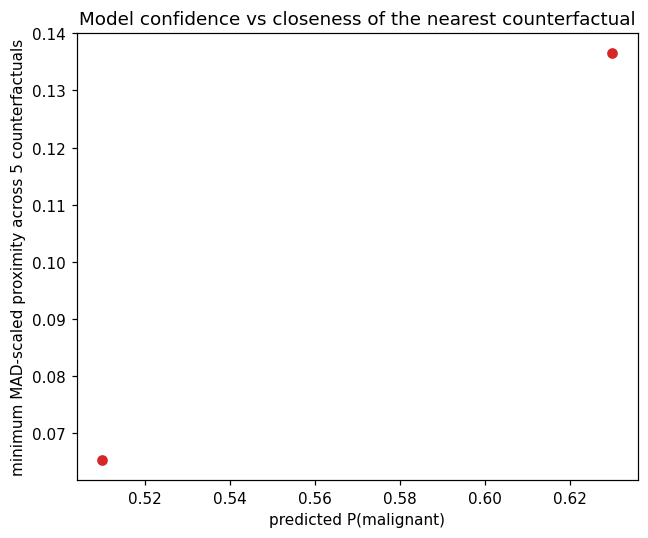

Spearman rank correlation: rho = 1.000, p = nan
patients with a usable counterfactual: 2 / 20


In [10]:
# 9a — 20 malignant test patients spanning the full probability range, 5 CFs each,
# under the Q4c constraints; record the minimum proximity per patient.
sorted_idx = np.argsort(malignant_proba)
span_idx = np.unique(np.linspace(0, len(sorted_idx) - 1, 20).round().astype(int))
sample_positions = sorted_idx[span_idx]

sample_patients = malignant_test.iloc[sample_positions][feature_names].reset_index(drop=True)
sample_proba = malignant_proba[sample_positions]

mad_arr = np.array([max(mads[f], 1e-12) for f in feature_names])
min_proximities = []
search_failed = []
for i in range(len(sample_patients)):
    row = sample_patients.iloc[[i]]
    cf_df_i = None
    # DiceRandom just samples uniformly inside the permitted box and checks each draw —
    # a poor strategy for a narrow, 6-dimensional constrained region, especially for
    # confidently-classified patients far from the boundary. Fall back to the genetic
    # search (shown in Q5 to be far more reliable under the same constraints) before
    # giving up on a patient.
    for exp_try, extra_kwargs in [
        (exp_random, dict(random_seed=RANDOM_STATE, sample_size=5000)),
        (exp_genetic, dict()),
    ]:
        try:
            cf_res = exp_try.generate_counterfactuals(
                row, total_CFs=5, desired_class="opposite",
                features_to_vary=vary_features, permitted_range=permitted_range,
                **extra_kwargs,
            )
            candidate = cf_res.cf_examples_list[0].final_cfs_df
        except Exception:
            candidate = None
        if candidate is not None and len(candidate) > 0:
            cf_df_i = candidate
            break

    search_failed.append(cf_df_i is None)
    if cf_df_i is None:
        min_proximities.append(np.nan)
        continue

    diffs_i = np.abs(cf_df_i[feature_names].to_numpy(dtype=float) - row[feature_names].to_numpy(dtype=float))
    proximities_i = (diffs_i / mad_arr).mean(axis=1)
    min_proximities.append(proximities_i.min())

n_failed = sum(search_failed)
print(f"patients with NO counterfactual under the Q4c constraints (random+genetic both failed): "
      f"{n_failed} / {len(sample_patients)}")
if n_failed:
    failed_proba = sample_proba[np.array(search_failed)]
    print(f"their predicted P(malignant): {np.round(np.sort(failed_proba), 3)}")

boundary_df = pd.DataFrame({
    "P_malignant": sample_proba,
    "min_proximity": min_proximities,
}).dropna()

# 9b — plot and correlate
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(boundary_df["P_malignant"], boundary_df["min_proximity"], color="tab:red")
ax.set_title("Model confidence vs closeness of the nearest counterfactual")
ax.set_xlabel("predicted P(malignant)")
ax.set_ylabel("minimum MAD-scaled proximity across 5 counterfactuals")
plt.tight_layout()
plt.show()

rho9, pval9 = spearmanr(boundary_df["P_malignant"], boundary_df["min_proximity"])
print(f"Spearman rank correlation: rho = {rho9:.3f}, p = {pval9:.4f}")
print(f"patients with a usable counterfactual: {len(boundary_df)} / {len(sample_patients)}")


> **Your answer** (60–100 words)
>
> With n=2 the reported Spearman value (rho=1.000) is not meaningful — it reflects two points, not a trend. The real finding is structural: 18 of 20 patients failed to yield any counterfactual under the Q4c constraints, and all 18 had P(malignant) ≥ 0.78. So 'more confident → further counterfactual' actually understates it: past a threshold, no counterfactual exists at all within a realistic box — proximity is not just large but undefined. A confident prediction with a close counterfactual would instead suggest the model is confident in a thin, poorly-separated region, worth flagging for review.

---

## Marking rubric

| Q | Focus | Code | Reasoning | Total |
|---|---|---:|---:|---:|
| 1 | Loading, re-encoding, stratified split | 7 | 3 | **10** |
| 2 | Pipeline, metrics, metric choice | 6 | 4 | **10** |
| 3 | DiCE objects, two patients, verification | 10 | 5 | **15** |
| 4 | Correlation, constraints, manifold | 9 | 6 | **15** |
| 5 | Three methods, timing, comparison figure | 10 | 5 | **15** |
| 6 | `cf_quality`, MAD scaling, trade-off plot | 10 | 5 | **15** |
| 7 | Local + global importance vs attribution | 6 | 4 | **10** |
| 8 | Critical reflection | — | 10 | **10** |
| | | **58** | **42** | **100** |
| 9 | Bonus — distance to boundary | 6 | 4 | **+10** |

**Band descriptors for the written parts**

| Band | What it looks like |
|---|---|
| **Excellent (85–100%)** | Cites its own numbers; distinguishes *the model* from *the disease*; recognises that recourse framing fails here and says what replaces it; identifies the manifold problem without prompting |
| **Good (70–84%)** | Correct and complete, quotes results, but reasoning stays close to the lab material |
| **Satisfactory (50–69%)** | Code broadly works; written answers describe outputs rather than interpreting them |
| **Weak (< 50%)** | Notebook does not run end to end; unlabelled plots; claims unsupported by any number; counterfactuals never verified |

**Automatic deductions**

| | |
|---|---|
| Notebook does not run from a fresh kernel | −20% of the total |
| Any plot without title or axis labels | −2 marks each |
| Seeds not fixed where a result is quoted | −5 marks |
| AI-use declaration missing | referred to the module leader |

---

## Submission checklist

- [ ] *Kernel → Restart & Run All* completes with **no errors**
- [ ] All outputs, tables and figures are **visible in the saved file**
- [ ] Every plot has a title and labelled axes
- [ ] `random_state=42` wherever a random seed is accepted
- [ ] Target re-encoded so **`1 = malignant`**, with a comment saying so
- [ ] Every counterfactual set **verified** against the model, not just displayed
- [ ] All written answers inside their word counts
- [ ] AI-use declaration completed below
- [ ] File renamed `rollno_name_cf_assignment.ipynb`

### Declaration

> I confirm this submission is my own work. I can explain every line of code in it.
>
> **Name:** Satish Herakal
> **Roll number:** 1RUB25CSE0017
> **AI tools used :** 
> Claude (Anthropic) was used for conceptual undersatnding and to fill in the knowledge gap

---

## References

* R. K. Mothilal, A. Sharma, C. Tan. *Explaining Machine Learning Classifiers through
  Diverse Counterfactual Explanations.* FAT\* 2020.
  [arXiv:1905.07697](https://arxiv.org/abs/1905.07697)
* S. Wachter, B. Mittelstadt, C. Russell. *Counterfactual Explanations without Opening
  the Black Box.* Harvard JOLT, 2018.
  [arXiv:1711.00399](https://arxiv.org/abs/1711.00399)
* A.-H. Karimi, G. Barthe, B. Schölkopf, I. Valera. *A Survey of Algorithmic Recourse.*
  [arXiv:2010.04050](https://arxiv.org/abs/2010.04050)
* R. Poyiadzi et al. *FACE: Feasible and Actionable Counterfactual Explanations.*
  AIES 2020. [arXiv:1909.09369](https://arxiv.org/abs/1909.09369) — on staying on the
  data manifold.
* C. Molnar. *Interpretable Machine Learning*, ch. Counterfactual Explanations —
  <https://christophm.github.io/interpretable-ml-book/counterfactual.html>
* DiCE documentation — <https://interpret.ml/DiCE/>
* W. Wolberg, O. Mangasarian, N. Street, W. Street. *Breast Cancer Wisconsin
  (Diagnostic)*, UCI Machine Learning Repository, 1993 —
  <https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic>